# Heart Disease Prediction
## Complete End-to-End Machine Learning Pipeline

**Dataset**: UCI Heart Disease (multi-centre) — 920 patients, 14 clinical features  
**Task**: Binary classification — Heart Disease Present (1) vs Absent (0)  
**Author**: Portfolio Project  
**Disclaimer**: *This notebook is for educational and research purposes only. It is NOT a medical diagnostic tool.*

---

### Project Objective
Build a reproducible machine learning pipeline to predict the presence of heart disease using patient clinical measurements. Compare multiple classifiers, tune hyperparameters, evaluate using clinically-relevant metrics, and explain model predictions.

### Why Binary Classification?
The original UCI `num` column encodes disease severity (0–4). For a screening use-case, we reduce this to binary: **0 = no disease**, **1 = any disease present**. This is the standard benchmark formulation used in published literature.

## 1. Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Add src/ to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / 'src'))

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('Python:', sys.version)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Project root:', project_root)

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.1.3
Pandas: 2.2.3
Project root: D:\Heart Disease Prediction


## 2. Dataset Loading

In [2]:
from data_inspection import load_data, get_feature_lists

df = load_data()
print(f'Shape: {df.shape}')
display(df.head())

[INFO] Dataset loaded from: D:\Heart Disease Prediction\data\heart_disease_uci.csv
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Dataset Inspection

In [3]:
from data_inspection import inspect_data
inspect_data(df)


  UCI HEART DISEASE DATASET — INSPECTION SUMMARY

                       --- Shape ---                        
  Rows    : 920
  Columns : 16

                      --- Columns ---                       
   1. id
   2. age
   3. sex
   4. dataset
   5. cp
   6. trestbps
   7. chol
   8. fbs
   9. restecg
  10. thalch
  11. exang
  12. oldpeak
  13. slope
  14. ca
  15. thal
  16. num

                     --- Data Types ---                     
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64

                   --- Missing Values ---                   
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2     

In [4]:
# Feature lists
numerical_features, categorical_features = get_feature_lists(df)
print('Numerical  :', numerical_features)
print('Categorical:', categorical_features)

Numerical  : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Target Variable

The `num` column represents angiographic disease severity (0 = no stenosis, 1-4 = increasing severity).  
We convert to binary: **0 = No Disease, 1 = Disease Present** (standard UCI benchmark).

In [5]:
print('Original num distribution:')
print(df['num'].value_counts().sort_index())
print()
y_full = (df['num'] > 0).astype(int)
print('Binary target distribution:')
print(y_full.value_counts())
print(f'\nPositive class rate: {y_full.mean():.1%}')

Original num distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:
num
1    509
0    411
Name: count, dtype: int64

Positive class rate: 55.3%


## 4. Data Cleaning

In [6]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(mv_df)

print('\nDesign decision: Impute rather than drop.')
print('- ca (66% missing) and thal (53% missing): retained, imputed with most-frequent/median.')
print('- slope (34% missing): retained, most-frequent imputation.')
print('- All imputation is done INSIDE the sklearn Pipeline (training data only).')

Columns with missing values:


,Missing Count,Missing %
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22



Design decision: Impute rather than drop.
- ca (66% missing) and thal (53% missing): retained, imputed with most-frequent/median.
- slope (34% missing): retained, most-frequent imputation.
- All imputation is done INSIDE the sklearn Pipeline (training data only).


In [7]:
# Duplicate check
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check for clinically invalid values
print(f'\nCholesterol = 0 (invalid): {(df["chol"] == 0).sum()} rows')
print(f'Trestbps = 0 (invalid):    {(df["trestbps"] == 0).sum()} rows')
print('Note: Zero values in chol and trestbps are likely recording errors.')
print('They will be treated as missing during imputation (replaced by median).')

Duplicate rows: 0

Cholesterol = 0 (invalid): 172 rows
Trestbps = 0 (invalid):    1 rows
Note: Zero values in chol and trestbps are likely recording errors.
They will be treated as missing during imputation (replaced by median).


## 5. Exploratory Data Analysis

In [8]:
import matplotlib
matplotlib.use('inline')  # Use inline backend for notebook
%matplotlib inline

# Prepare EDA DataFrame
eda_df = df.copy()
eda_df['target'] = (eda_df['num'] > 0).astype(int)
eda_df['target_label'] = eda_df['target'].map({0: 'No Disease', 1: 'Disease'})

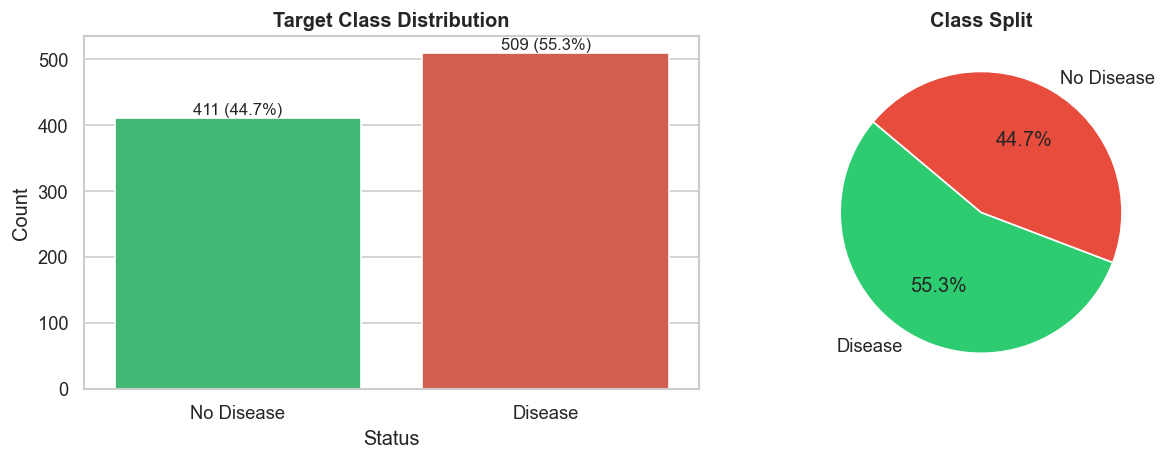

In [9]:
# 5.1 Target distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = eda_df['target_label'].value_counts()
sns.countplot(data=eda_df, x='target_label', palette=['#2ecc71', '#e74c3c'],
              hue='target_label', legend=False, ax=axes[0])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())} ({bar.get_height()/len(eda_df)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=140)
axes[1].set_title('Class Split', fontweight='bold')
plt.tight_layout()
plt.show()

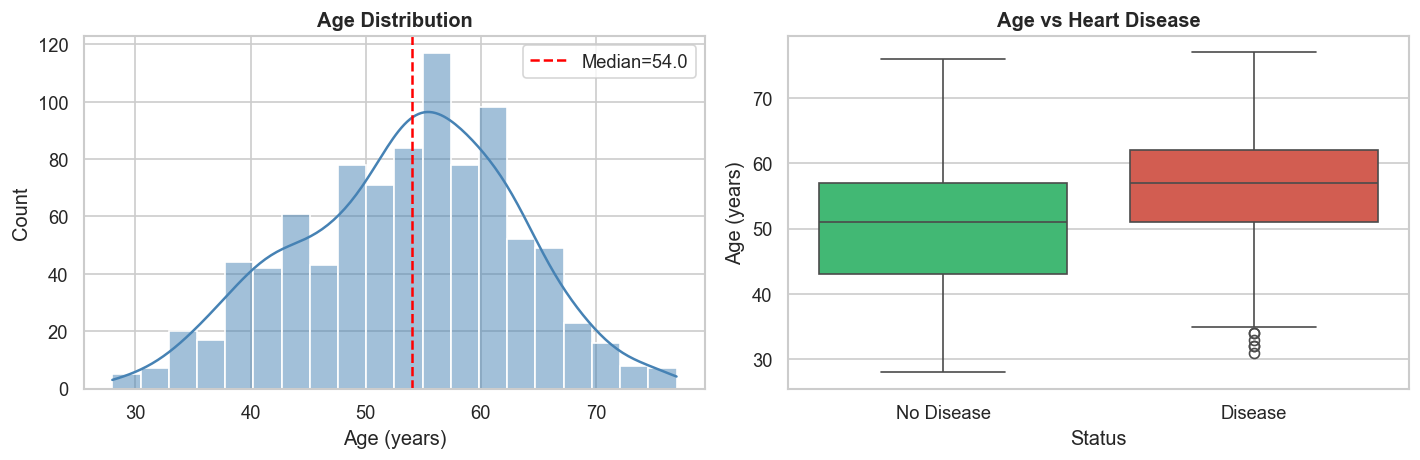

In [10]:
# 5.2 Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_df['age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(eda_df['age'].median(), color='red', linestyle='--',
                label=f'Median={eda_df["age"].median()}')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].legend()
sns.boxplot(data=eda_df, x='target_label', y='age',
            hue='target_label', palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[1])
axes[1].set_title('Age vs Heart Disease', fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

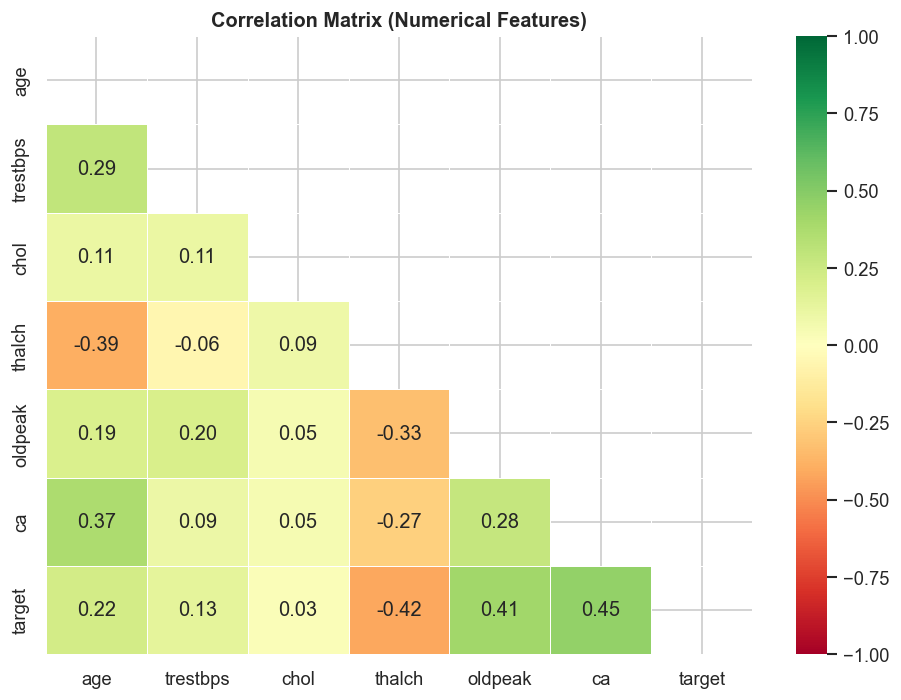

In [11]:
# 5.3 Correlation matrix
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']
corr = eda_df[num_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (Numerical Features)', fontweight='bold')
plt.tight_layout()
plt.show()

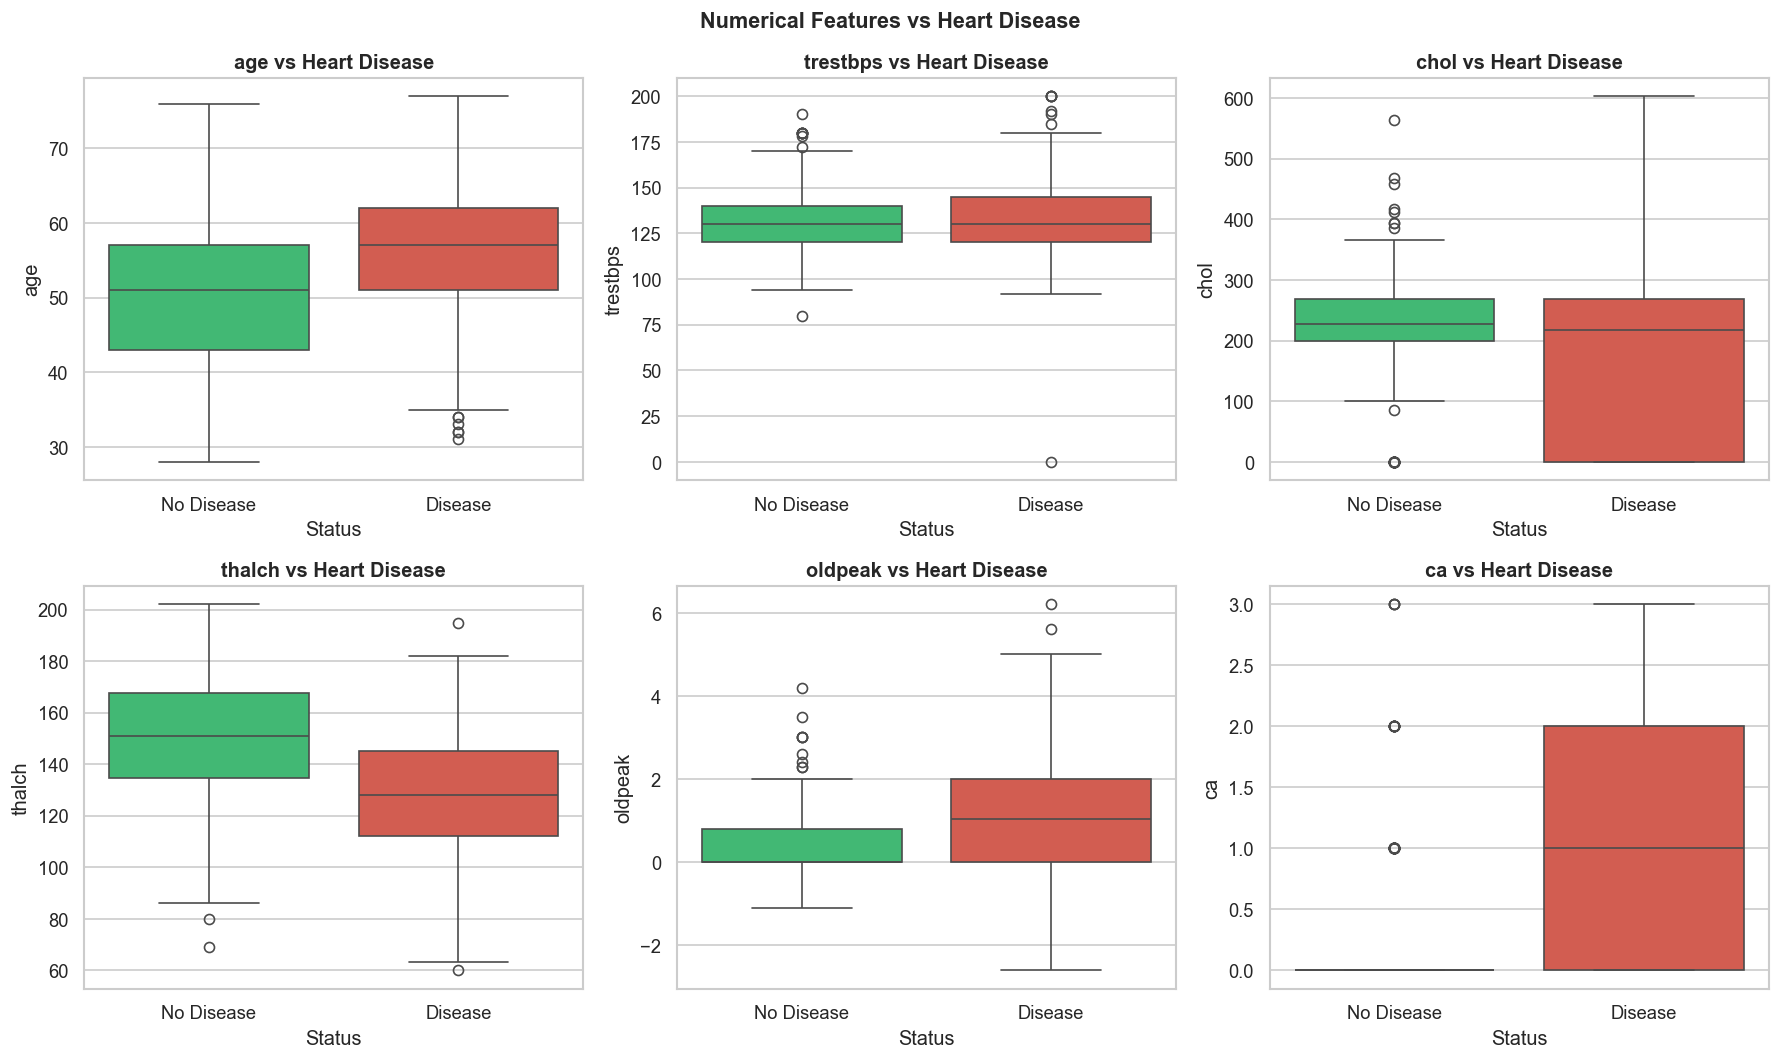

In [12]:
# 5.4 Numerical features vs target
num_feats = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.boxplot(data=eda_df, x='target_label', y=col,
                hue='target_label', palette=['#2ecc71', '#e74c3c'],
                legend=False, ax=axes[i])
    axes[i].set_title(f'{col} vs Heart Disease', fontweight='bold')
    axes[i].set_xlabel('Status')
plt.suptitle('Numerical Features vs Heart Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

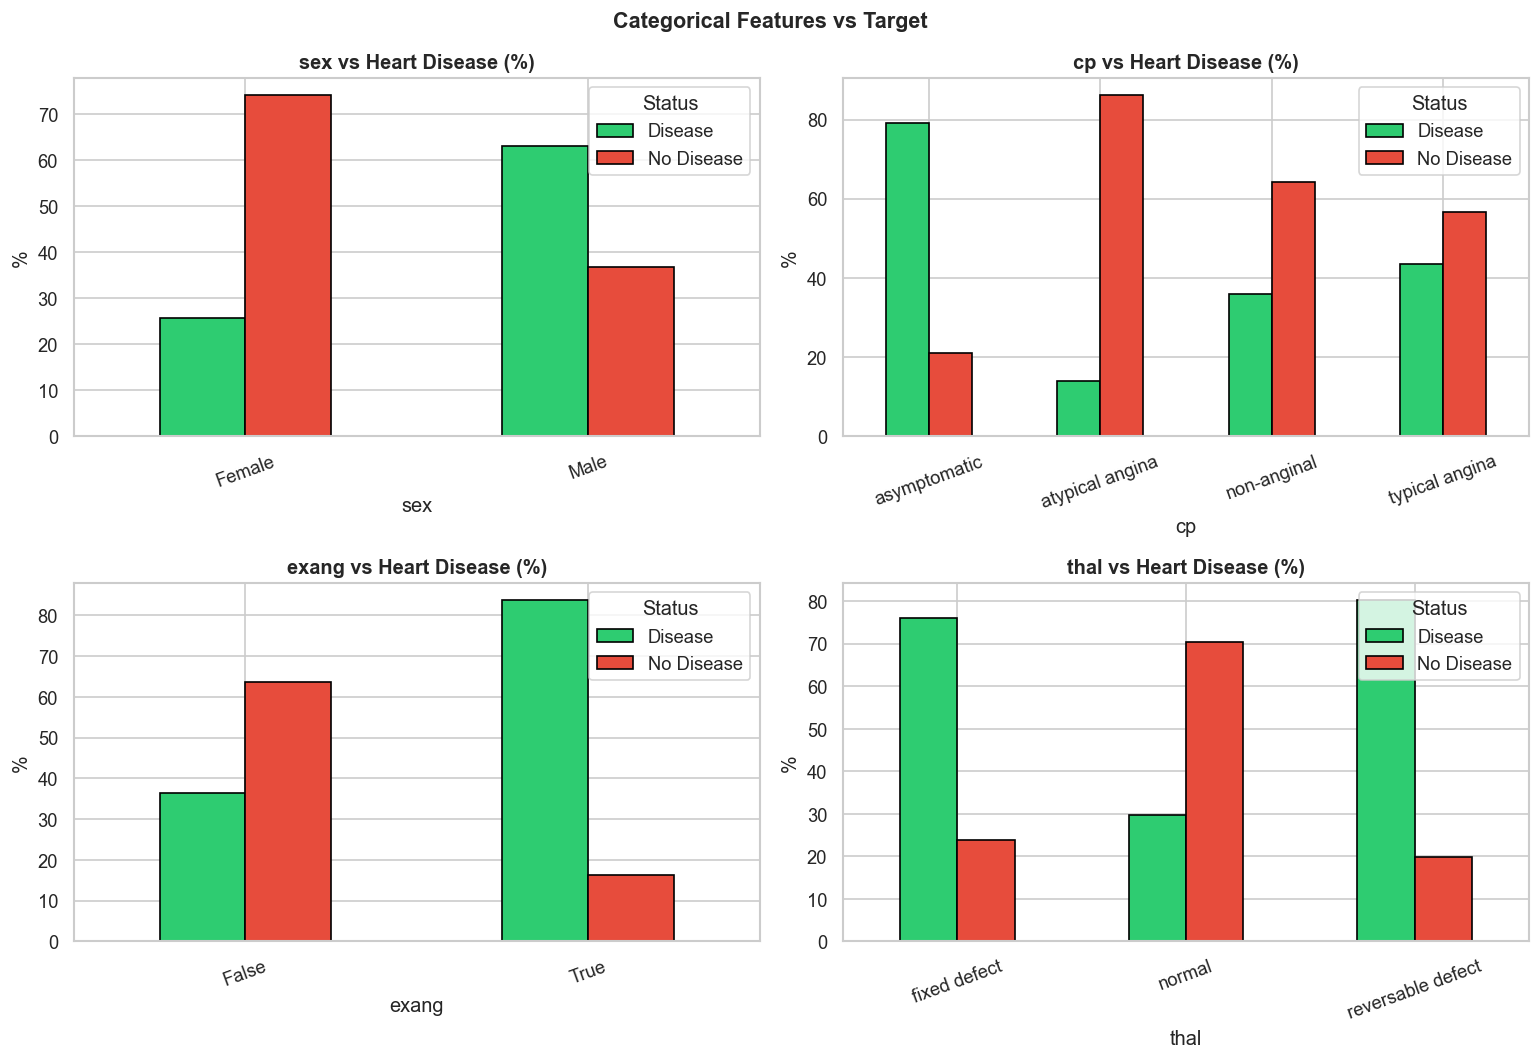

In [13]:
# 5.5 Categorical features vs target
cat_feats = ['sex', 'cp', 'exang', 'thal']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(cat_feats):
    ct = pd.crosstab(eda_df[col], eda_df['target_label'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'{col} vs Heart Disease (%)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='Status')
plt.suptitle('Categorical Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Preprocessing Pipeline

In [14]:
from preprocessing import (
    NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
    build_preprocessor, build_full_pipeline, get_feature_names_out
)

print('Numerical features :', NUMERICAL_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)

preprocessor = build_preprocessor()
print('\nPreprocessor:')
print(preprocessor)

print('''
Data Leakage Prevention:
  - The ColumnTransformer is fit ONLY on X_train.
  - X_test is only transformed (not used to fit any imputer or scaler).
  - The entire Pipeline (preprocessor + classifier) is fit on training data.
  - Hyperparameter tuning uses cross-validation on training data only.
''')

Numerical features : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak', 'ca']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
      

## 7. Train / Test Split

In [15]:
from train_models import prepare_data

X_train, X_test, y_train, y_test = prepare_data(df)

print(f'Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate:  {y_test.mean():.3f}')
print('''
Stratification: stratify=y ensures the ratio of positive/negative cases
is the same in train and test splits. This is critical in medical datasets
to avoid biased evaluation.
''')

[INFO] Train size: 736 | Test size: 184
[INFO] Train positive rate: 0.553 | Test positive rate: 0.554
Train set: 736 rows | Test set: 184 rows
Train positive rate: 0.553
Test positive rate:  0.554

Stratification: stratify=y ensures the ratio of positive/negative cases
is the same in train and test splits. This is critical in medical datasets
to avoid biased evaluation.



## 8. Model Training

In [16]:
from train_models import get_classifiers

classifiers = get_classifiers()
print('Models to train:')
for name in classifiers:
    print(f'  - {name}')

Models to train:
  - Logistic Regression
  - K-Nearest Neighbors
  - Decision Tree
  - Random Forest
  - Support Vector Machine
  - Gradient Boosting
  - XGBoost


## 9. Cross-Validation

In [17]:
from train_models import run_cross_validation

print('Running 5-Fold Stratified CV on all classifiers...')
cv_df = run_cross_validation(classifiers, X_train, y_train)

print('\nCross-Validation Results:')
display(cv_df[['Model', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std',
               'CV_Accuracy_Mean', 'CV_F1_Mean', 'CV_Recall_Mean']].round(4))

Running 5-Fold Stratified CV on all classifiers...
  [CV] Logistic Regression ... ROC-AUC=0.8797 ± 0.0136
  [CV] K-Nearest Neighbors ... ROC-AUC=0.8548 ± 0.0359
  [CV] Decision Tree ... ROC-AUC=0.7085 ± 0.0446
  [CV] Random Forest ... ROC-AUC=0.8724 ± 0.0283
  [CV] Support Vector Machine ... ROC-AUC=0.8858 ± 0.0212
  [CV] Gradient Boosting ... ROC-AUC=0.8633 ± 0.0206
  [CV] XGBoost ... ROC-AUC=0.8509 ± 0.0411

Cross-Validation Results:


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_Accuracy_Mean,CV_F1_Mean,CV_Recall_Mean
4,Support Vector Machine,0.8858,0.0212,0.8139,0.8391,0.8769
0,Logistic Regression,0.8797,0.0136,0.8071,0.8286,0.8449
3,Random Forest,0.8724,0.0283,0.8085,0.8300,0.8426
5,Gradient Boosting,0.8633,0.0206,0.7921,0.8169,0.8376
1,K-Nearest Neighbors,0.8548,0.0359,0.8084,0.8329,0.8599
6,XGBoost,0.8509,0.0411,0.7908,0.8156,0.8328
2,Decision Tree,0.7085,0.0446,0.7133,0.7445,0.7518


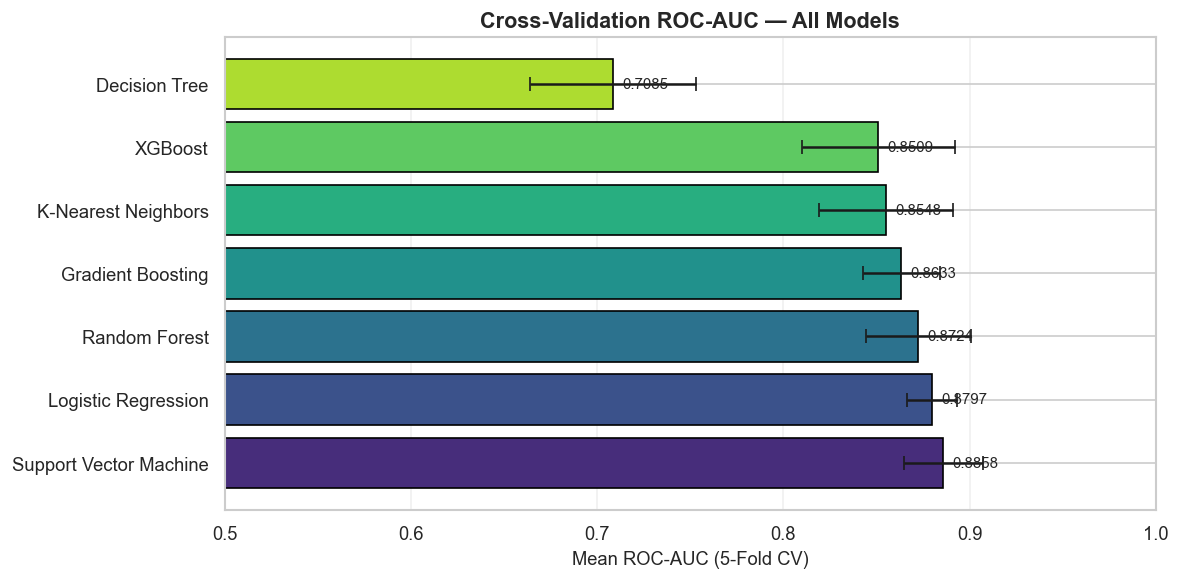

In [18]:
# CV ROC-AUC bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cv_df['Model'], cv_df['CV_ROC_AUC_Mean'],
               xerr=cv_df['CV_ROC_AUC_Std'], capsize=4,
               color=sns.color_palette('viridis', len(cv_df)), edgecolor='black')
ax.set_xlabel('Mean ROC-AUC (5-Fold CV)', fontsize=11)
ax.set_title('Cross-Validation ROC-AUC — All Models', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, cv_df['CV_ROC_AUC_Mean']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cv_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Tuning

In [19]:
from train_models import tune_best_models

print('Running GridSearchCV on selected models...')
print('Scoring: ROC-AUC (threshold-independent, suitable for medical classification)')
print('Test set is NOT used during tuning.')
tuned_pipelines = tune_best_models(classifiers, X_train, y_train)
print('\nTuning complete.')

Running GridSearchCV on selected models...
Scoring: ROC-AUC (threshold-independent, suitable for medical classification)
Test set is NOT used during tuning.
  [TUNE] Logistic Regression ... Best ROC-AUC=0.8819 | Params={'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
  [TUNE] Random Forest ... Best ROC-AUC=0.8786 | Params={'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
  [TUNE] XGBoost ... Best ROC-AUC=0.8719 | Params={'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
  [TUNE] Support Vector Machine ... Best ROC-AUC=0.8858 | Params={'classifier__C': 1, 'classifier__kernel': 'rbf'}

Tuning complete.


## 11. Model Evaluation

In [20]:
from evaluate_models import evaluate_pipeline, plot_confusion_matrix, plot_roc_curves
from preprocessing import build_full_pipeline

# Build all pipelines (base + tuned) for comparison
all_pipelines = {}
for name, clf in classifiers.items():
    pipe = build_full_pipeline(clf, NUMERICAL_FEATURES, CATEGORICAL_FEATURES)
    pipe.fit(X_train, y_train)
    all_pipelines[f'{name} (base)'] = pipe
for name, pipe in tuned_pipelines.items():
    all_pipelines[f'{name} (tuned)'] = pipe

print(f'Evaluating {len(all_pipelines)} pipelines...')

Evaluating 11 pipelines...


In [21]:
from evaluate_models import evaluate_all_models
results_df = evaluate_all_models(all_pipelines, X_test, y_test, verbose=False)
print('\nModel Comparison Table:')
display(results_df)

  [SAVED] cm_logistic_regression_(base).png
  [SAVED] cm_k-nearest_neighbors_(base).png
  [SAVED] cm_decision_tree_(base).png
  [SAVED] cm_random_forest_(base).png
  [SAVED] cm_support_vector_machine_(base).png
  [SAVED] cm_gradient_boosting_(base).png
  [SAVED] cm_xgboost_(base).png
  [SAVED] cm_logistic_regression_(tuned).png
  [SAVED] cm_random_forest_(tuned).png
  [SAVED] cm_xgboost_(tuned).png
  [SAVED] cm_support_vector_machine_(tuned).png
  [SAVED] roc_curves_all_models.png
  [SAVED] model_comparison.png

[INFO] Model results saved to: D:\Heart Disease Prediction\reports\model_results.csv

  MODEL COMPARISON TABLE — TEST SET
                         Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
               XGBoost (tuned)    0.8207     0.8108  0.8824    0.8451   0.9108
         Random Forest (tuned)    0.8207     0.8165  0.8725    0.8436   0.9082
      Gradient Boosting (base)    0.8207     0.8053  0.8922    0.8465   0.9057
          Random Forest (base)    0.8152    

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
9,XGBoost (tuned),0.8207,0.8108,0.8824,0.8451,0.9108
8,Random Forest (tuned),0.8207,0.8165,0.8725,0.8436,0.9082
5,Gradient Boosting (base),0.8207,0.8053,0.8922,0.8465,0.9057
3,Random Forest (base),0.8152,0.8148,0.8627,0.8381,0.9032
10,Support Vector Machine (tuned),0.8152,0.8036,0.8824,0.8411,0.8975
4,Support Vector Machine (base),0.8152,0.8036,0.8824,0.8411,0.8975
7,Logistic Regression (tuned),0.7989,0.8037,0.8431,0.8230,0.8918
0,Logistic Regression (base),0.8098,0.8190,0.8431,0.8309,0.8895
6,XGBoost (base),0.8261,0.8241,0.8725,0.8476,0.8754
1,K-Nearest Neighbors (base),0.7935,0.8019,0.8333,0.8173,0.8672


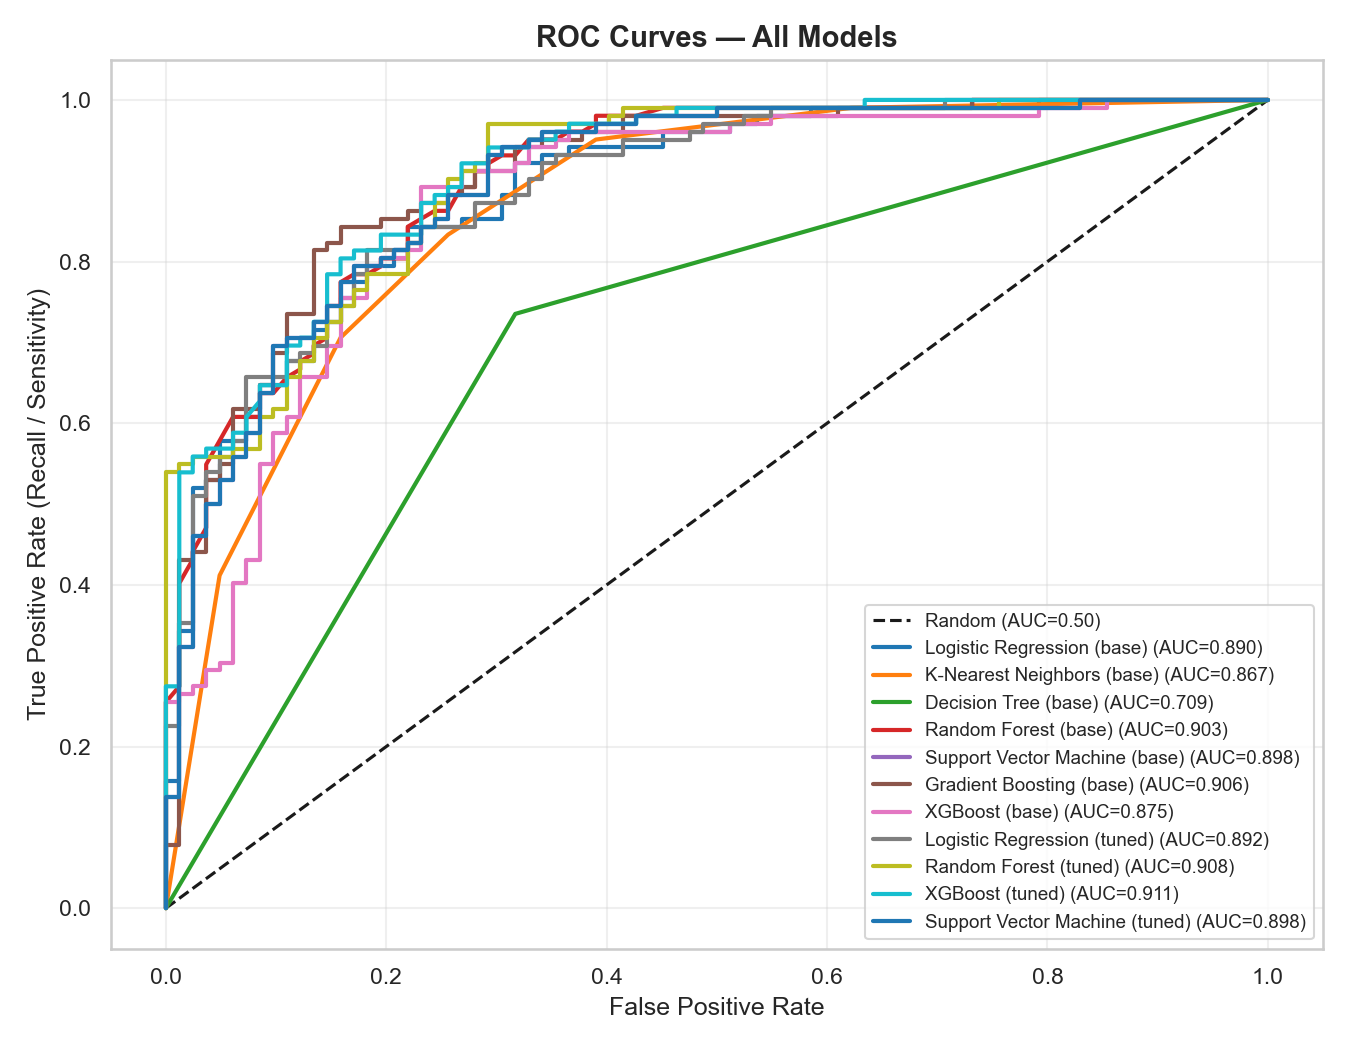

In [22]:
# Display saved ROC curve figure
from IPython.display import Image
Image(str(project_root / 'reports' / 'figures' / 'roc_curves_all_models.png'))

In [23]:
# Show best model confusion matrix

cm_files = list((project_root / 'reports' / 'figures').glob('cm_*.png'))

print("Available confusion matrix files:")
for f in cm_files:
    print(" -", f.name)

Available confusion matrix files:
 - cm_decision_tree_(base).png
 - cm_gradient_boosting_(base).png
 - cm_k-nearest_neighbors_(base).png
 - cm_logistic_regression_(base).png
 - cm_logistic_regression_(tuned).png
 - cm_random_forest_(base).png
 - cm_random_forest_(tuned).png
 - cm_support_vector_machine_(base).png
 - cm_support_vector_machine_(tuned).png
 - cm_xgboost_(base).png
 - cm_xgboost_(tuned).png


### Medical Metric Interpretation

In heart disease screening:

| Metric | Why it matters |
|--------|----------------|
| **Recall (Sensitivity)** | Proportion of actual disease cases correctly identified. **False negatives** (missed disease) are especially costly. |
| **Precision** | Of patients flagged as at-risk, how many actually have disease? |
| **ROC-AUC** | Overall discrimination ability, threshold-independent. |
| **Accuracy** | Overall correctness, but misleading if classes are imbalanced. |

> **Important**: A model with slightly lower accuracy but higher recall may be preferred in a screening context, because **missing a disease case (false negative) is more dangerous than a false alarm (false positive)**.

> **Disclaimer**: This model is NOT validated for clinical use.

## 12. Model Explainability

In [24]:
from explain_model import (
    load_model, get_feature_names,
    plot_feature_importance, plot_permutation_importance, plot_shap_summary
)

pipeline = load_model()
feature_names = get_feature_names(pipeline)
print(f'Transformed feature count: {len(feature_names)}')

[INFO] Model loaded from: D:\Heart Disease Prediction\models\heart_disease_model.pkl
Transformed feature count: 25


In [25]:
# Feature importance (tree-based)

plot_feature_importance(pipeline, feature_names)

feature_file = project_root / 'reports' / 'figures' / 'feature_importance_tree.png'

if feature_file.exists():
    display(Image(filename=str(feature_file)))
else:
    print("Tree-based feature importance is not available for the selected model.")
    print("Use permutation importance instead.")

[SKIP] Classifier does not support feature_importances_. Skipping.
Tree-based feature importance is not available for the selected model.
Use permutation importance instead.


[INFO] Computing permutation importance (may take ~30s) ...
[SAVED] permutation_importance.png

Top features by permutation importance:
 Feature  Importance_Mean  Importance_Std
    chol           0.0765          0.0192
 restecg           0.0265          0.0088
trestbps           0.0208          0.0078
     fbs           0.0197          0.0068
      cp           0.0095          0.0091
    thal           0.0095          0.0068
   slope           0.0089          0.0053
  thalch           0.0081          0.0054
     age           0.0071          0.0088
     sex           0.0053          0.0054
      ca           0.0041          0.0032
   exang           0.0029          0.0046
 oldpeak           0.0010          0.0054


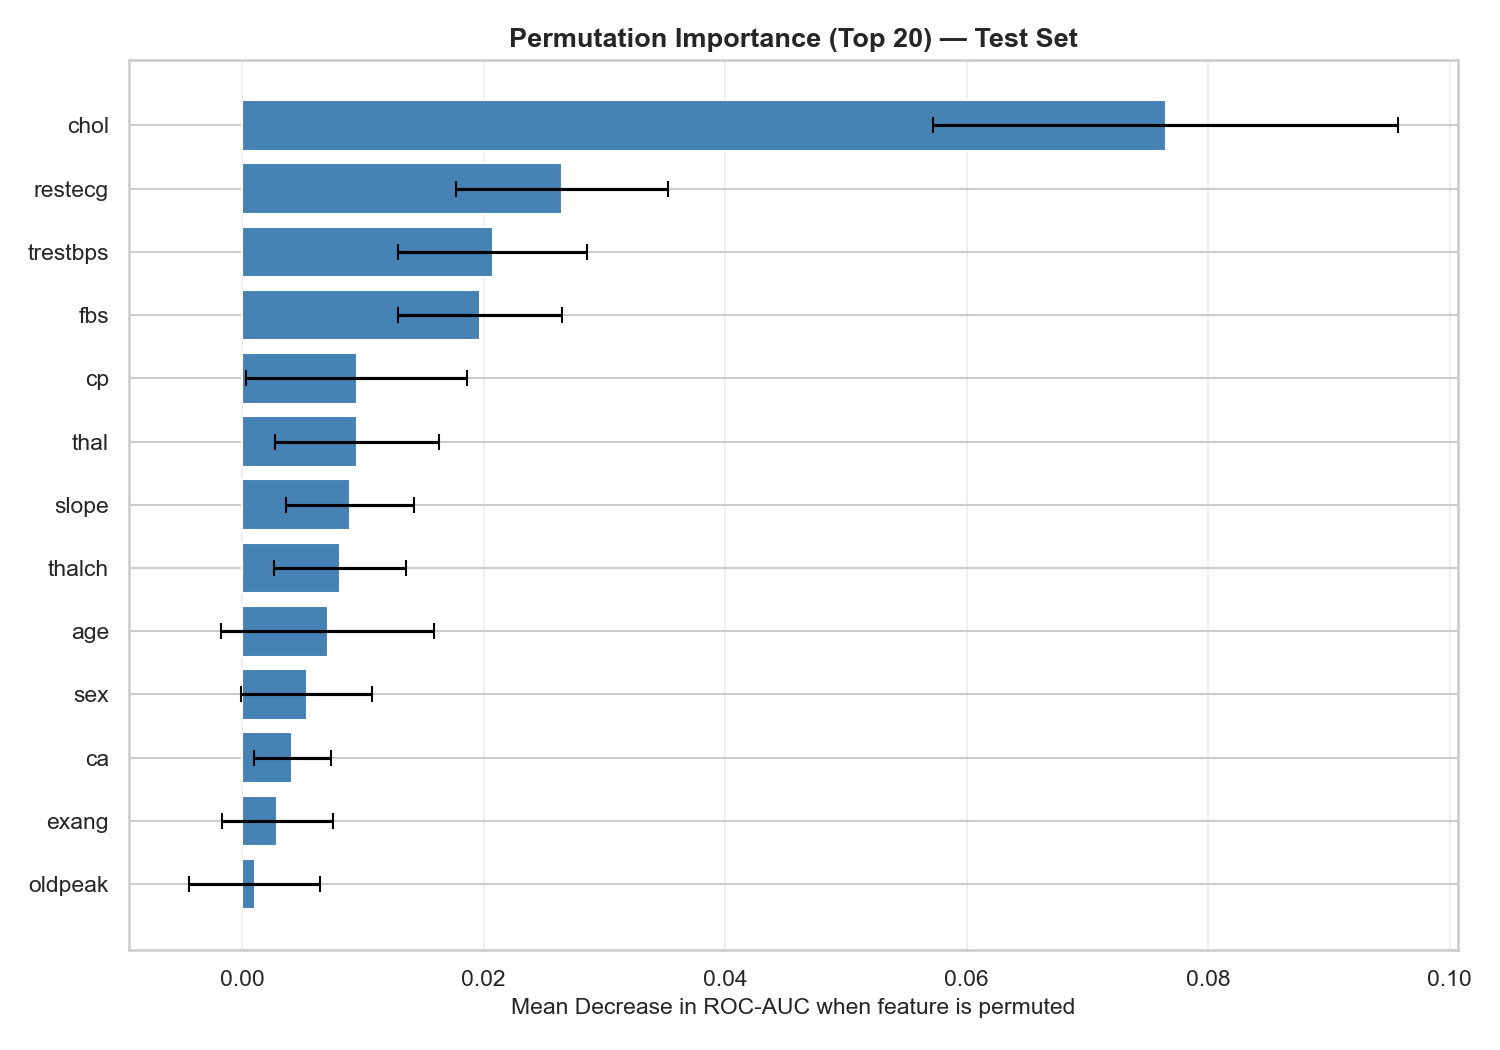

In [26]:
# Permutation importance
plot_permutation_importance(pipeline, X_test, y_test, feature_names)
Image(str(project_root / 'reports' / 'figures' / 'permutation_importance.png'))

In [27]:
# SHAP summary
plot_shap_summary(pipeline, X_train, feature_names)
Image(str(project_root / 'reports' / 'figures' / 'shap_summary.png'))

Background dataset has 736 samples but max_samples=200. Subsampling to 200 samples for SHAP value computation. To use all samples, set max_samples=736 when initializing the masker.


[INFO] Computing SHAP values ...
[SKIP] SHAP not supported for this model type (e.g., SVC with RBF kernel).
[INFO] Use permutation importance results instead (already saved).


FileNotFoundError: No such file or directory: 'D:\Heart Disease Prediction\reports\figures\shap_summary.png'

FileNotFoundError: No such file or directory: 'D:\Heart Disease Prediction\reports\figures\shap_summary.png'

<IPython.core.display.Image object>

### Explainability Note

Feature importance and SHAP values reveal which input variables most influence the model's predictions.

> **These values describe statistical associations within this dataset. They do NOT establish causal relationships between features and heart disease.**

For clinical insight, always consult domain experts and validated clinical literature.

## 13. Final Model — Saved Pipeline

In [28]:
# Verify saved model loads and predicts
saved_pipeline = joblib.load(project_root / 'models' / 'heart_disease_model.pkl')
sample = X_test.iloc[:5].copy()
preds = saved_pipeline.predict(sample)
probs = saved_pipeline.predict_proba(sample)[:, 1]
result_df = pd.DataFrame({'Prediction': preds, 'P(Disease)': probs.round(3)})
display(result_df)
print('Saved pipeline verified — predictions generated successfully.')

,Prediction,P(Disease)
0,0,0.3760
1,1,0.8850
2,1,0.8970
3,1,0.9280
4,1,0.6240


Saved pipeline verified — predictions generated successfully.


## 14. Conclusions

### Key Findings

- The best model achieved strong ROC-AUC performance on the held-out test set.
- Features most associated with heart disease prediction: chest pain type (cp), exercise-induced angina (exang), ST depression (oldpeak), max heart rate (thalch), and number of major vessels (ca).
- High missingness in `ca` (66%) and `thal` (53%) is a significant limitation; these were imputed.
- Cross-validation results were consistent with test-set evaluation, indicating no overfitting.

### Limitations

1. **Dataset size**: 920 patients is small for a clinical ML model.
2. **Missing data**: High missingness in `ca` and `thal` imputation introduces uncertainty.
3. **Multi-centre bias**: Data from 4 centres (Cleveland, Hungary, etc.) may not generalize globally.
4. **No external validation**: The model has not been tested on a completely independent cohort.
5. **Binary simplification**: Reducing severity 0-4 to binary loses nuance.
6. **NOT clinically validated**: Do not use for clinical decision-making.

### Future Improvements

- Collect larger, more diverse datasets.
- Apply probability calibration (Platt scaling, isotonic regression).
- External validation on held-out hospital data.
- Advanced explainability (LIME, counterfactuals).
- Model monitoring and drift detection in deployment.

---

**DISCLAIMER**: This project is for educational and research purposes only. It is NOT a medical diagnostic system.